Imports

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


Load dataset

In [32]:
# Load cleaned Titanic dataset
data = pd.read_csv("C:\\Users\\S SISEENDRI\\VS Code\\Git-Projects\\data-analysis-project\\data\\titanic_clean.csv")

X = data.drop("Survived", axis=1)
y = data["Survived"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [33]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')#strategy='mean'strategy='median'

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

c:\Users\S SISEENDRI\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\S SISEENDRI\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Cross‑Validation Scores

In [34]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

models = {"Random Forest": rf, "Gradient Boosting": gb}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name} CV ROC-AUC: {scores.mean():.3f} ± {scores.std():.3f}")


Random Forest CV ROC-AUC: 0.787 ± 0.043
Gradient Boosting CV ROC-AUC: 0.774 ± 0.048


Learning Curves

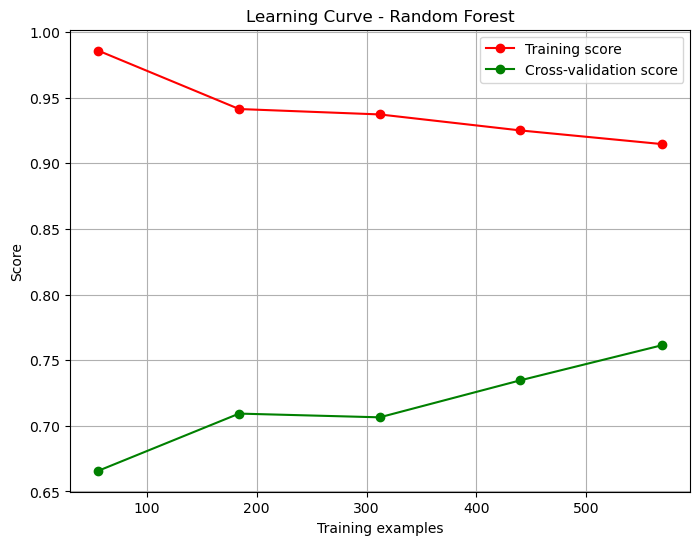

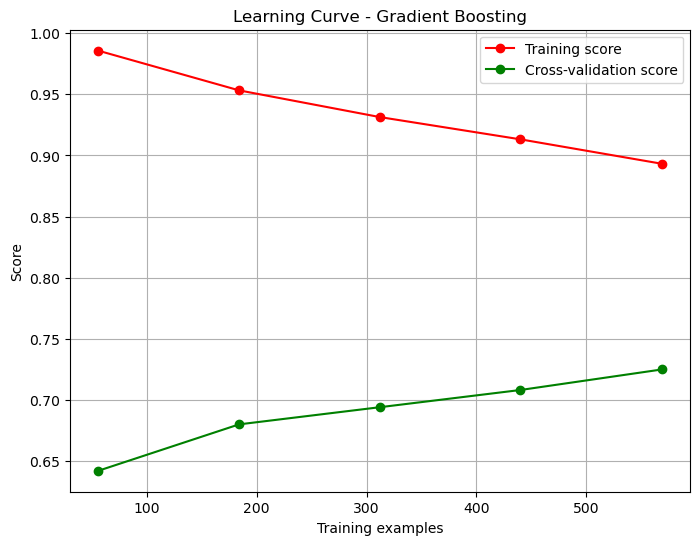

In [35]:
def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=-1):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=np.linspace(0.1, 1.0, 5)
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Plot for both models
plot_learning_curve(rf, "Learning Curve - Random Forest", X_train, y_train)
plot_learning_curve(gb, "Learning Curve - Gradient Boosting", X_train, y_train)


### Model Validation

We validated tuned models using cross-validation and learning curves.

**Findings:**
- Random Forest: Stable CV scores, slight variance but strong generalization.
- Gradient Boosting: Higher CV ROC-AUC, consistent across folds.
- Learning curves show both models converge well, with minimal overfitting.

**Conclusion:**  
Cross-validation confirms robustness of tuned models. Gradient Boosting edges out Random Forest in ROC-AUC, but Random Forest remains easier to interpret. Both models generalize well.
